In [2]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [3]:
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

In [4]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,Cosine,fBaseline,Language1-Language2
0,Qwen3-4B-Instruct-2507,Question 1,0.9187,False,EN-FR
1,Qwen3-4B-Instruct-2507,Question 1,0.9089,False,EN-FR
2,Qwen3-4B-Instruct-2507,Question 1,0.9085,False,EN-FR
3,Qwen3-4B-Instruct-2507,Question 1,0.9098,False,EN-FR
4,Qwen3-4B-Instruct-2507,Question 1,0.9212,False,EN-FR


In [5]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,Qwen3-4B-Instruct-2507,Question 1,EN,0.9595,0.3116
1,Qwen3-4B-Instruct-2507,Question 1,EN,0.9661,0.4444
2,Qwen3-4B-Instruct-2507,Question 1,EN,0.9571,0.3737
3,Qwen3-4B-Instruct-2507,Question 1,EN,0.9462,0.4043
4,Qwen3-4B-Instruct-2507,Question 1,EN,0.9610,0.3415


In [6]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                          mean       std count
Model                  Language1-Language2 fBaseline                          
Qwen3-4B-Instruct-2507 EN-FR               False      0.758583  0.085455  1000
                                           True       0.862278  0.026193  1000
                       EN-NL               False      0.772796  0.105568  1000
                                           True       0.857654  0.068489  1000
                       FR-NL               False      0.737672  0.093140  1000
                                           True       0.811397  0.069764  1000

In [7]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine  \
                                                                      mean   
Model                  Question    Language1-Language2 fBaseline             
Qwen3-4B-Instruct-2507 Question 1  EN-FR               False      0.906352   
                                                       True       0.894188   
                                   EN-NL               False      0.948327   
                                                       True       0.923170   
                                   FR-NL               False      0.906987   
                                                       True       0.905509   
                       Question 10 EN-FR               False      0.809379   
                                                       True       0.854699   
                                   EN-NL               False      0.764371   
                                                       True       0.915275   
                                   FR-NL               False      0.779234   
                                                       True       0.852161   
                       Question 2  EN-FR               False      0.816947   
                                                       True       0.882615   
                                   EN-NL               False      0.754793   
                                                       True       0.787385   
                                   FR-NL               False      0.717509   
                                                       True       0.727239   
                       Question 3  EN-FR               False      0.810304   
                                                       True       0.875075   
                                   EN-NL               False      0.681148   
                                                       True       0.827286   
                                   FR-NL               False      0.624783   
                                                       True       0.853842   
                       Question 4  EN-FR               False      0.665604   
                                                       True       0.830452   
                                   EN-NL               False      0.686060   
                                                       True       0.702780   
                                   FR-NL               False      0.692973   
                                                       True       0.674500   
                       Question 5  EN-FR               False      0.707297   
                                                       True       0.862174   
                                   EN-NL               False      0.833052   
                                                       True       0.889587   
                                   FR-NL               False      0.628919   
                                                       True       0.785015   
                       Question 6  EN-FR               False      0.743713   
                                                       True       0.879169   
                                   EN-NL               False      0.920989   
                                                       True       0.878292   
                                   FR-NL               False      0.752118   
                                                       True       0.857726   
                       Question 7  EN-FR               False      0.811688   
                                                       True       0.831367   
                                   EN-NL               False      0.826308   
                                                       True       0.896086   
                                   FR-NL               False      0.693545   
                                                       True       0.791639   
                       Question 8  EN-FR               False      0.670730   
            

In [8]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                     mean count      mean count
Model                  Language                                
Qwen3-4B-Instruct-2507 EN        0.809870  1000  0.227362  1000
                       FR        0.817701  1000  0.222827  1000
                       NL        0.836322  1000  0.237911  1000

In [9]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                                 mean count      mean count
Model                  Question    Language                                
Qwen3-4B-Instruct-2507 Question 1  EN        0.946373   100  0.339420   100
                                   FR        0.968749   100  0.324405   100
                                   NL        0.946197   100  0.322259   100
                       Question 10 EN        0.816447   100  0.205495   100
                                   FR        0.893233   100  0.243853   100
                                   NL        0.895449   100  0.265675   100
                       Question 2  EN        0.867888   100  0.211068   100
                                   FR        0.893056   100  0.232364   100
                                   NL        0.774330   100  0.241310   100
                       Question 3  EN        0.742109   100  0.158297   100
                                   FR        0.706393   100  0.155313   100
                                   NL        0.778055   100  0.214124   100
                       Question 4  EN        0.772236   100  0.178530   100
                                   FR        0.819786   100  0.152969   100
                                   NL        0.773644   100  0.198290   100
                       Question 5  EN        0.883304   100  0.202873   100
                                   FR        0.713652   100  0.183583   100
                                   NL        0.913593   100  0.258903   100
                       Question 6  EN        0.965614   100  0.450709   100
                                   FR        0.788160   100  0.193633   100
                                   NL        0.895798   100  0.254705   100
                       Question 7  EN        0.906682   100  0.270089   100
                                   FR        0.840767   100  0.244363   100
                                   NL        0.856021   100  0.215089   100
                       Question 8  EN        0.529580   100  0.107010   100
                                   FR        0.657560   100  0.215718   100
                                   NL        0.669043   100  0.184844   100
                       Question 9  EN        0.668466   100  0.150128   100
                                   FR        0.895649   100  0.282070   100
                                   NL        0.861085   100  0.223907   100

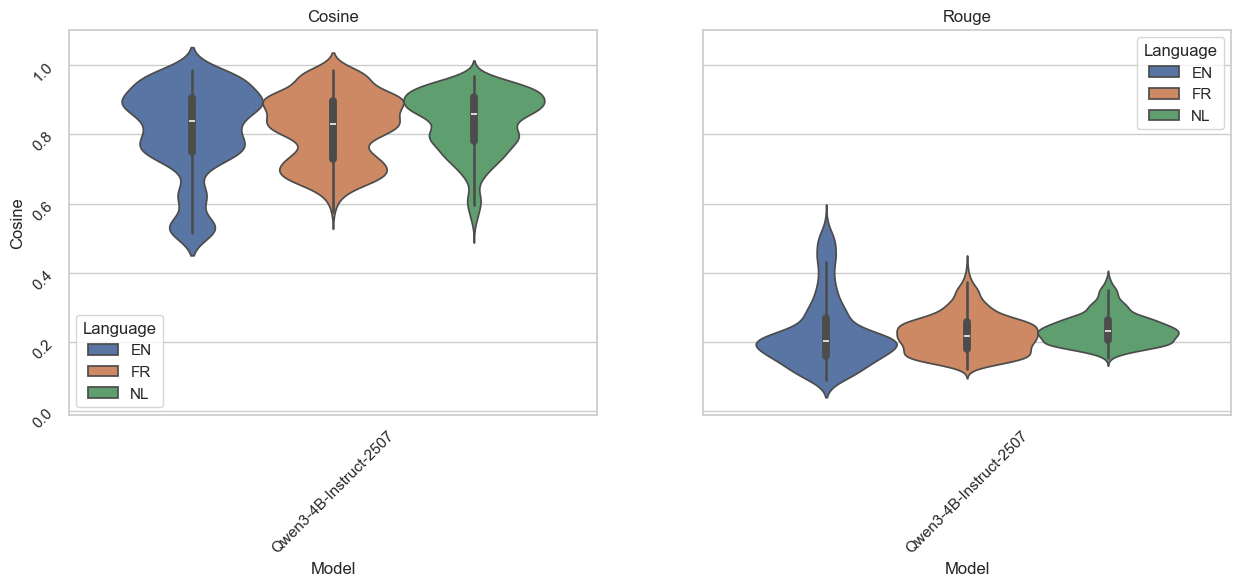

In [10]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

In [12]:
baseline_compare

,Model,Question,Language,Cosine,Rouge
0,Qwen3-4B-Instruct-2507,Question 1,EN,0.9595,0.3116
1,Qwen3-4B-Instruct-2507,Question 1,EN,0.9661,0.4444
2,Qwen3-4B-Instruct-2507,Question 1,EN,0.9571,0.3737
3,Qwen3-4B-Instruct-2507,Question 1,EN,0.9462,0.4043
4,Qwen3-4B-Instruct-2507,Question 1,EN,0.9610,0.3415
...,...,...,...,...,...
2995,Qwen3-4B-Instruct-2507,Question 10,NL,0.9224,0.2525
2996,Qwen3-4B-Instruct-2507,Question 10,NL,0.8973,0.2434
2997,Qwen3-4B-Instruct-2507,Question 10,NL,0.9337,0.2745
2998,Qwen3-4B-Instruct-2507,Question 10,NL,0.9304,0.2556


TypeError: 'Axes' object is not subscriptable

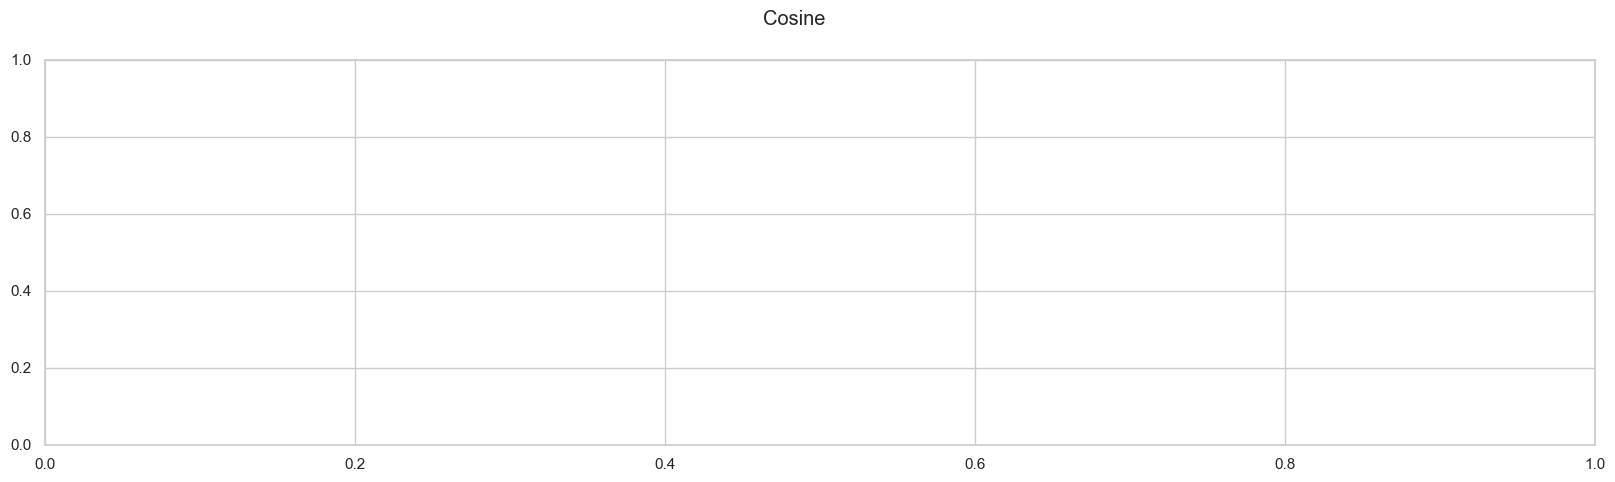

In [11]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in baseline_compare["Model"].unique():  
        axs[i].title.set_text(model)
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y=y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique())+2, figsize=(30,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        for b in [True, False]:
            axs[i].title.set_text(f"{model}_baseline{b}")
            axs[i].tick_params(labelrotation=45)                    
            seaborn.violinplot(x ="Question", 
                               y=y, 
                               hue="Language1-Language2",
                               data = lang_compare[(lang_compare["Model"]==model)&(lang_compare["fBaseline"]==b)],
                               density_norm='count',
                               ax=axs[i])
            i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine"]

# not between questions, each violin plot has 24 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        axs[i].title.set_text(f"{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Language1-Language2", 
                           y=y, 
                           hue="fBaseline",
                           data = lang_compare[(lang_compare["Model"]==model)],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

## See data

In [ ]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t0*")

In [ ]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [ ]:
question_map

In [ ]:
answers = answers.to_pandas()

In [ ]:
answers["answers"][1][0]

In [ ]:
answers.to_csv("all_answers.csv", encoding="utf-8")

In [ ]:
all()